# Python para GIS — Aula 3
## Operações Espaciais Avançadas, Fiona e Estudo de Caso

**Objetivo:** Dominar operações espaciais um pouco mais complexas com GeoPandas, realizar spatial queries, aprender a ler e escrever formatos geoespaciais com Fiona, e integrar tudo num estudo de caso real.

---

## Fiona — Leitura de dados geoespaciais

**Fiona** é a biblioteca Python que faz a interface com a **OGR**, a parte de dados vetoriais da GDAL (Geospatial Data Abstraction Library). Enquanto o GeoPandas é ótimo para análise, Fiona é a ferramenta de mais baixo nível para **ler e escrever** arquivos geoespaciais.

### Por que aprender Fiona se já temos GeoPandas?

1. **Iteração eficiente** sobre feições sem carregar tudo em memória
2. **Controle fino** sobre schema, campos e metadados ao escrever
3. **Acesso direto** a formatos que o GeoPandas pode não suportar bem
4. **Entender** o que acontece por baixo dos panos quando você chama `gpd.read_file()`

In [9]:
import fiona
import os

shp_path = "saida/pontos_coleta.shp"

if os.path.exists(shp_path):
    with fiona.open(shp_path) as src:
        print("Metadados da fonte")
        print("  Motor (driver):", src.driver)
        print("  CRS:", src.crs)
        print("  Número de feições:", len(src))
        print("  Extensão (bounds):", src.bounds)
        print("\n  Schema:")
        print("    Geometria:", src.schema["geometry"])
        print("    Propriedades:", src.schema["properties"])
else:
    print(f"Arquivo {shp_path} não encontrado. Execute a Aula 1 primeiro para gerá-lo.")

Metadados da fonte
  Motor (driver): ESRI Shapefile
  CRS: 
  Número de feições: 6
  Extensão (bounds): (-46.66, -23.57, -46.62, -23.54)

  Schema:
    Geometria: Point
    Propriedades: {'id': 'int:18', 'data': 'str:80', 'parametro': 'str:80', 'valor': 'float:24.15', 'x': 'float:24.15', 'y': 'float:24.15'}


In [10]:
if os.path.exists(shp_path):
    with fiona.open(shp_path) as src:
        print("=== Iterando sobre as feições ===\n")
        for i, feature in enumerate(src):
            print(f"Feição {i+1}:")
            print(f"  ID: {feature['id']}")
            print(f"  Geometria: {feature['geometry']['type']}")
            print(f"  Coordenadas: {feature['geometry']['coordinates']}")
            print(f"  Propriedades: {feature['properties']}")
            print()

=== Iterando sobre as feições ===

Feição 1:
  ID: 0
  Geometria: Point
  Coordenadas: (-46.63, -23.55)
  Propriedades: fiona.Properties(id=1, data='2024-01-15', parametro='pH', valor=6.8, x=-46.63, y=-23.55)

Feição 2:
  ID: 1
  Geometria: Point
  Coordenadas: (-46.64, -23.56)
  Propriedades: fiona.Properties(id=2, data='2024-01-15', parametro='turbidez', valor=12.3, x=-46.64, y=-23.56)

Feição 3:
  ID: 2
  Geometria: Point
  Coordenadas: (-46.65, -23.55)
  Propriedades: fiona.Properties(id=3, data='2024-01-15', parametro='pH', valor=7.1, x=-46.65, y=-23.55)

Feição 4:
  ID: 3
  Geometria: Point
  Coordenadas: (-46.62, -23.54)
  Propriedades: fiona.Properties(id=4, data='2024-01-16', parametro='oxigenio', valor=5.2, x=-46.62, y=-23.54)

Feição 5:
  ID: 4
  Geometria: Point
  Coordenadas: (-46.66, -23.57)
  Propriedades: fiona.Properties(id=5, data='2024-01-16', parametro='pH', valor=6.9, x=-46.66, y=-23.57)

Feição 6:
  ID: 5
  Geometria: Point
  Coordenadas: (-46.63, -23.56)
  Propri

### Estrutura de uma fonte Fiona:

```
src (Collection)
├── .driver      → "ESRI Shapefile", "GeoJSON", "GPKG"...
├── .crs         → CRS da fonte
├── .schema      → Estrutura (tipo de geometria + campos)
├── .bounds      → Extensão espacial
└── iteração     → Cada item é um dict {"id", "geometry", "properties"}
```

> Uma **feição** (feature) é a unidade fundamental do GIS vetorial: **geometria + atributos**. O GeoDataFrame representa cada **feature** como uma linha e a geometria como a coluna `geometry`.

## Fiona — Escrita de dados geoespaciais

Para criar um arquivo geoespacial do zero com Fiona, precisamos definir:
1. O **schema** (tipo de geometria + propriedades)
2. O **CRS**
3. As **feições** (geometria + atributos)

In [11]:
from shapely.geometry import Point, Polygon, mapping
import geopandas as gpd 

schema = {
    "geometry": "Polygon",
    "properties": {
        "nome": "str",
        "area_km2": "float",
        "populacao": "int",
    }
}

bairros = [
    {
        "geometry": mapping(Polygon([(0, 0), (3, 0), (3, 3), (0, 3)])),
        "properties": {"nome": "Centro", "area_km2": 9.0, "populacao": 5000},
    },
    {
        "geometry": mapping(Polygon([(3, 0), (7, 0), (7, 3), (3, 3)])),
        "properties": {"nome": "Jardins", "area_km2": 12.0, "populacao": 3000},
    },
    {
        "geometry": mapping(Polygon([(0, 3), (3, 3), (3, 7), (0, 7)])),
        "properties": {"nome": "Industrial", "area_km2": 12.0, "populacao": 1500},
    },
    {
        "geometry": mapping(Polygon([(3, 3), (7, 3), (7, 7), (3, 7)])),
        "properties": {"nome": "Universitário", "area_km2": 16.0, "populacao": 8000},
    },
]

output_path = "saida/bairros.shp"

with fiona.open(
    output_path, "w",
    driver="ESRI Shapefile",
    schema=schema,
    crs="EPSG:4326",
) as dst:
    for bairro in bairros:
        dst.write(bairro)

print(f"Arquivo criado: {output_path}")

bairros_gdf = gpd.read_file(output_path)
bairros_gdf

Arquivo criado: saida/bairros.shp


,nome,area_km2,populacao,geometry
0,Centro,9.0,5000,"POLYGON ((0 0, 0 3, 3 3, 3 0, 0 0))"
1,Jardins,12.0,3000,"POLYGON ((3 0, 3 3, 7 3, 7 0, 3 0))"
2,Industrial,12.0,1500,"POLYGON ((0 3, 0 7, 3 7, 3 3, 0 3))"
3,Universitário,16.0,8000,"POLYGON ((3 3, 3 7, 7 7, 7 3, 3 3))"


> **`mapping()` do Shapely** converte uma geometria Shapely para o formato GeoJSON-like (dict) que a Fiona espera. É a ponte entre as duas bibliotecas.

## Spatial Join — Unindo dados pela localização

Um **spatial join** (`sjoin`) é como um JOIN de SQL, mas a condição de junção é **espacial** em vez de igualdade de chaves. Exemplo clássico: "Quais escolas estão dentro de cada bairro?"

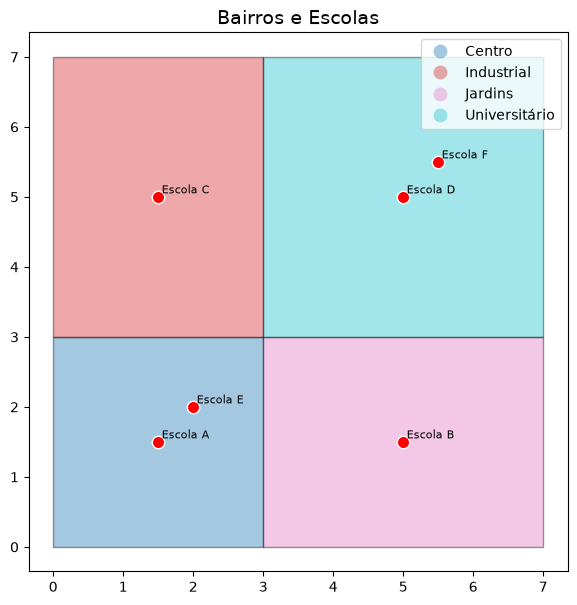

In [12]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

escolas = gpd.GeoDataFrame({
    "nome": ["Escola A", "Escola B", "Escola C", "Escola D", "Escola E", "Escola F"],
    "tipo": ["Municipal", "Estadual", "Municipal", "Estadual", "Municipal", "Particular"],
    "alunos": [300, 500, 200, 450, 350, 600],
    "geometry": [
        Point(1.5, 1.5),
        Point(5.0, 1.5),
        Point(1.5, 5.0),
        Point(5.0, 5.0),
        Point(2.0, 2.0),
        Point(5.5, 5.5),
    ]
}, crs="EPSG:4326")

fig, ax = plt.subplots(figsize=(7, 7))
bairros_gdf.plot(ax=ax, column="nome", alpha=0.4, edgecolor="black", legend=True)
escolas.plot(ax=ax, color="red", markersize=80, edgecolor="white", linewidth=1)

for idx, row in escolas.iterrows():
    ax.text(row.geometry.x + 0.05, row.geometry.y + 0.05, row["nome"], fontsize=8)

ax.set_title("Bairros e Escolas", fontsize=14)
ax.set_aspect("equal")
plt.show()

In [13]:
escolas

,nome,tipo,alunos,geometry
0,Escola A,Municipal,300,POINT (1.5 1.5)
1,Escola B,Estadual,500,POINT (5 1.5)
2,Escola C,Municipal,200,POINT (1.5 5)
3,Escola D,Estadual,450,POINT (5 5)
4,Escola E,Municipal,350,POINT (2 2)
5,Escola F,Particular,600,POINT (5.5 5.5)


In [14]:
bairros_gdf

,nome,area_km2,populacao,geometry
0,Centro,9.0,5000,"POLYGON ((0 0, 0 3, 3 3, 3 0, 0 0))"
1,Jardins,12.0,3000,"POLYGON ((3 0, 3 3, 7 3, 7 0, 3 0))"
2,Industrial,12.0,1500,"POLYGON ((0 3, 0 7, 3 7, 3 3, 0 3))"
3,Universitário,16.0,8000,"POLYGON ((3 3, 3 7, 7 7, 7 3, 3 3))"


In [15]:
# aqui estamos com um spatial join, unindo em um unico geodataframe todas as escolas que estão dentro de um bairro
escolas_por_bairro = gpd.sjoin(escolas, 
                               bairros_gdf, 
                               how="inner",  #inner, outer  
                               predicate="within",
                               lsuffix='left',
                               rsuffix='right'
                               )
escolas_por_bairro

,nome_left,tipo,alunos,geometry,index_right,nome_right,area_km2,populacao
0,Escola A,Municipal,300,POINT (1.5 1.5),0,Centro,9.0,5000
1,Escola B,Estadual,500,POINT (5 1.5),1,Jardins,12.0,3000
2,Escola C,Municipal,200,POINT (1.5 5),2,Industrial,12.0,1500
3,Escola D,Estadual,450,POINT (5 5),3,Universitário,16.0,8000
4,Escola E,Municipal,350,POINT (2 2),0,Centro,9.0,5000
5,Escola F,Particular,600,POINT (5.5 5.5),3,Universitário,16.0,8000


In [16]:
contagem = escolas_por_bairro.groupby("nome_right").agg(
    total_escolas=("nome_left", "count"),
    total_alunos=("alunos", "sum"),
).reset_index()
contagem

,nome_right,total_escolas,total_alunos
0,Centro,2,650
1,Industrial,1,200
2,Jardins,1,500
3,Universitário,2,1050


In [17]:
contagem.columns = ["bairro", "total_escolas", "total_alunos"]
contagem

,bairro,total_escolas,total_alunos
0,Centro,2,650
1,Industrial,1,200
2,Jardins,1,500
3,Universitário,2,1050


### Parâmetros do `sjoin`:

| Parâmetro | Opções | Descrição |
|---|---|---|
| `how` | `"inner"`, `"left"`, `"right"` | Tipo de join (como SQL) |
| `predicate` | `"intersects"` (default), `"within"`, `"contains"`, `"touches"`, `"crosses"`, `"overlaps"` | Condição espacial de junção |
| `lsuffix`, `rsuffix` | strings | Sufixos para colunas com mesmo nome |

> `predicate="within"` encontra cada escola **dentro** de um bairro. `predicate="intersects"` é mais permissivo e incluiria escolas na fronteira.

## 3.4 Overlay — Sobreposição de camadas

Enquanto o `sjoin` transfere atributos entre camadas, o **overlay** cria **novas geometrias** a partir da sobreposição. É como aplicar as operações de conjunto do Shapely (Aula 0) em DataFrames inteiros.

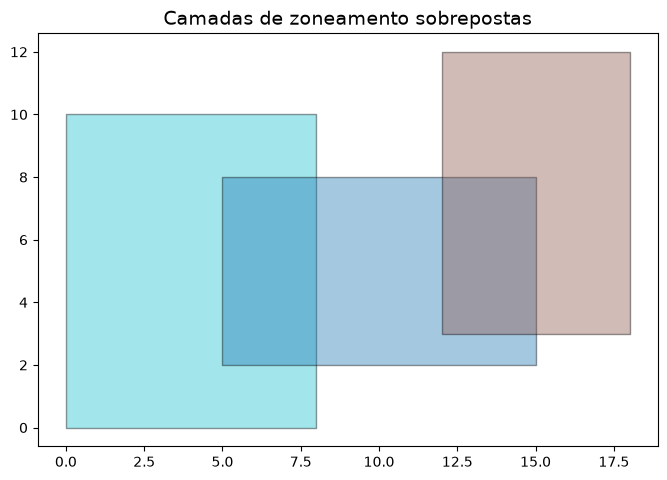

In [18]:
from shapely.geometry import box

zonas = gpd.GeoDataFrame({
    "zona": ["Residencial", "Comercial", "Parque"],
    "restricao": ["Altura máx 15m", "Altura máx 50m", "Construção proibida"],
    "geometry": [
        box(0, 0, 8, 10),
        box(5, 2, 15, 8),
        box(12, 3, 18, 12),
    ]
}, crs="EPSG:4326")

fig, ax = plt.subplots(figsize=(8, 6))
zonas.plot(ax=ax, column="zona", alpha=0.4, edgecolor="black")
ax.set_title("Camadas de zoneamento sobrepostas", fontsize=14)
ax.set_aspect("equal")
plt.show()

In [19]:
type(zonas.iloc[[0]])

geopandas.geodataframe.GeoDataFrame

In [20]:
intersecao = gpd.overlay(zonas.iloc[[0]], 
                         zonas.iloc[[1]], 
                         how="intersection"
                         )

print("Interseção entre Residencial e Comercial:")
print(f"  Área total: {intersecao.area.sum():.2f}")
print(f"  Feições geradas: {len(intersecao)}")
#intersecao.plot()

Interseção entre Residencial e Comercial:
  Área total: 18.00
  Feições geradas: 1


/var/folders/4c/l7p5k11j33q2m2b550gssyhm0000gn/T/ipykernel_13165/3936655476.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  print(f"  Área total: {intersecao.area.sum():.2f}")


In [21]:

uniao = gpd.overlay(zonas.iloc[[0]], zonas.iloc[[1]], how="union")
print("\nUnião entre Residencial e Comercial:")
print(f"  Área total: {uniao.area.sum():.2f}")
print(f"  Feições geradas: {len(uniao)}")



União entre Residencial e Comercial:
  Área total: 122.00
  Feições geradas: 3


/var/folders/4c/l7p5k11j33q2m2b550gssyhm0000gn/T/ipykernel_13165/2060133221.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  print(f"  Área total: {uniao.area.sum():.2f}")


In [22]:

diferenca = gpd.overlay(zonas.iloc[[0]], zonas.iloc[[1]], how="difference")
print("\nResidencial menos Comercial:")
print(f"  Área restante: {diferenca.area.sum():.2f}")


Residencial menos Comercial:
  Área restante: 62.00


/var/folders/4c/l7p5k11j33q2m2b550gssyhm0000gn/T/ipykernel_13165/2729210938.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  print(f"  Área restante: {diferenca.area.sum():.2f}")


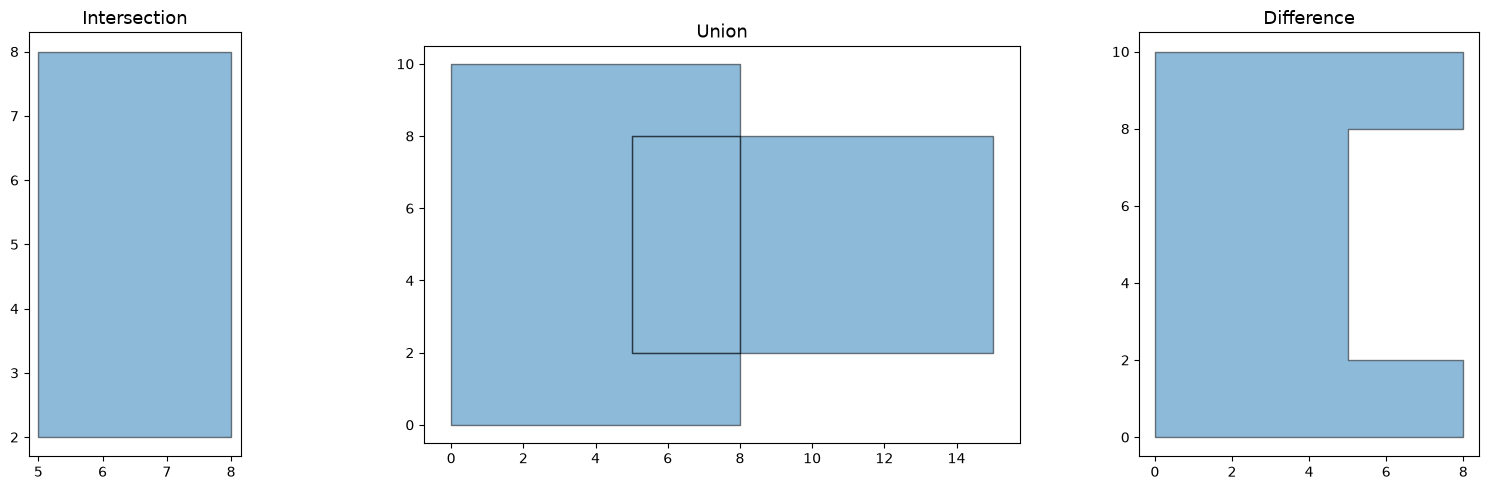

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, gdf, titulo in [
    (axes[0], intersecao, "Intersection"),
    (axes[1], uniao, "Union"),
    (axes[2], diferenca, "Difference"),
]:
    gdf.plot(ax=ax, alpha=0.5, edgecolor="black")
    ax.set_title(titulo, fontsize=13)
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

| `how` | Resultado | Equivalente Shapely |
|---|---|---|
| `"intersection"` | Área comum às duas camadas | `.intersection()` |
| `"union"` | Todas as áreas combinadas (pode gerar múltiplas geometrias) | `.union()` |
| `"difference"` | Área da primeira camada excluindo a segunda | `.difference()` |
| `"symmetric_difference"` | Área exclusiva de cada camada | `.symmetric_difference()` |
| `"identity"` | Primeira camada + atributos das sobreposições com a segunda | — |

## 3.5 Transformação de CRS (`.to_crs()`)

Na Aula 1 usamos `.set_crs()` para **declarar** o CRS. Agora vamos `.to_crs()` para **converter** de um CRS para outro.

### Por que reprojetar?

- **EPSG:4326** (WGS 84) usa graus → não serve para medir área, distância ou fazer buffer em metros
- **EPSG:5641** (SIRGAS2000) Sistema Geodesico de referencia, expresso em graus 
- **CRS projetados** (UTM, SIRGAS 2000 / UTM, Albers) usam metros → permitem cálculos métricos precisos

**Regra de ouro:** Sempre reprojete para um CRS plano (metros) antes de fazer buffer, calcular área ou distância.

Leia mais sobre o Sirgas2000: https://geosense.com.br/2025/05/07/wgs84-ou-sirgas-2000-voce-sabe-mesmo-qual-usar/

Como achar o UTM rapidamente: https://utmzone.optimumgeospatial.co.ke/


In [24]:
pts = gpd.GeoDataFrame({
    "nome": ["São Paulo", "Rio de Janeiro", "Brasília"],
    "geometry": [
        Point(-46.63, -23.55),
        Point(-43.20, -22.91),
        Point(-47.93, -15.78),
    ]
}, crs="EPSG:4326") # WGS84

print("Coordenadas em WGS 84 (graus):")
for idx, row in pts.iterrows():
    print(f"  {row['nome']}: x={row.geometry.x:.2f}, y={row.geometry.y:.2f}")

pts_utm = pts.to_crs("EPSG:31983")

print("\nCoordenadas em SIRGAS2000 UTM 23S (metros):")
for idx, row in pts_utm.iterrows():
    print(f"  {row['nome']}: x={row.geometry.x:,.0f}m, y={row.geometry.y:,.0f}m")

Coordenadas em WGS 84 (graus):
  São Paulo: x=-46.63, y=-23.55
  Rio de Janeiro: x=-43.20, y=-22.91
  Brasília: x=-47.93, y=-15.78

Coordenadas em SIRGAS2000 UTM 23S (metros):
  São Paulo: x=333,624m, y=7,394,648m
  Rio de Janeiro: x=684,610m, y=7,465,314m
  Brasília: x=186,057m, y=8,253,215m


Buffer de 100 km no CRS geográfico (ERRADO):
  Diâmetro aproximado: ~222 km (1 grau ≈ 111 km)

Buffer de 100 km no CRS projetado (CORRETO):
  Raio exato: 100,000 m


/var/folders/4c/l7p5k11j33q2m2b550gssyhm0000gn/T/ipykernel_13165/2042013157.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  buf_errado = buf_geo.buffer(1.0)


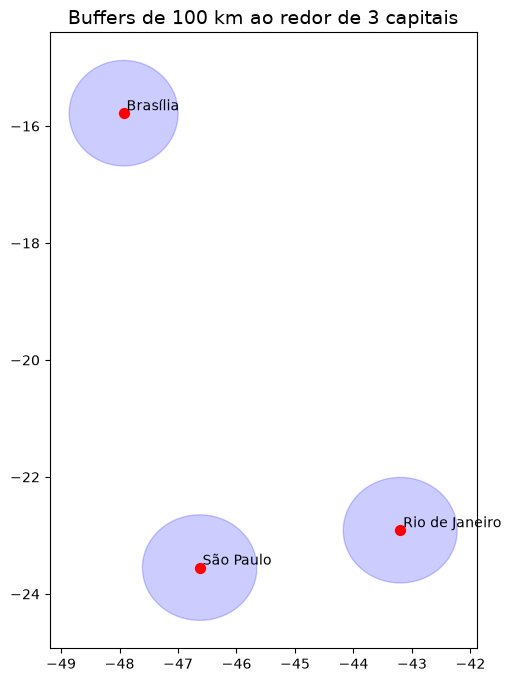

In [25]:
print("Buffer de 100 km no CRS geográfico (ERRADO):")
buf_geo = pts.to_crs("EPSG:4326")

buf_errado = buf_geo.buffer(1.0)
print(f"  Diâmetro aproximado: ~{2 * 111:.0f} km (1 grau ≈ 111 km)")

print("\nBuffer de 100 km no CRS projetado (CORRETO):")
buf_correto = pts_utm.buffer(100000)
print(f"  Raio exato: 100,000 m")

buf_correto_geo = buf_correto.to_crs("EPSG:4326")

fig, ax = plt.subplots(figsize=(10, 8))
buf_correto_geo.plot(ax=ax, alpha=0.2, color="blue", edgecolor="blue")
pts.plot(ax=ax, color="red", markersize=50)

for idx, row in pts.iterrows():
    ax.text(row.geometry.x + 0.05, row.geometry.y + 0.05, row["nome"], fontsize=10)

ax.set_title("Buffers de 100 km ao redor de 3 capitais", fontsize=14)
ax.set_aspect("equal")
plt.show()

### Como descobrir o EPSG da sua região?

1. Acesse [epsg.io](https://epsg.io/)
2. Busque por "Brazil" + sua região
3. No Brasil, o CRS oficial é **SIRGAS 2000**:
   - EPSG:4674 → SIRGAS 2000 geográfico
   - EPSG:31983 → SIRGAS 2000 / UTM zone 23S (SP, RJ, MG)
   - EPSG:31984 → SIRGAS 2000 / UTM zone 24S (ES, BA, SE)
   - EPSG:31985 → SIRGAS 2000 / UTM zone 25S (Nordeste oriental)

## Dissolve e Agregação Espacial

**Dissolve** une geometrias vizinhas que compartilham um mesmo valor de atributo. Exemplo clássico: dissolver municípios para criar o polígono do estado.

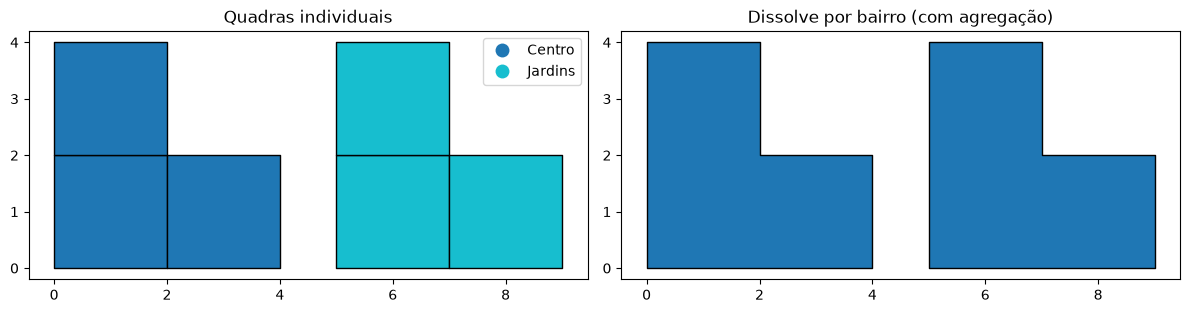

,geometry,populacao
bairro,,
Centro,"POLYGON ((0 0, 0 2, 0 4, 2 4, 2 2, 4 2, 4 0, 2...",450
Jardins,"POLYGON ((5 0, 5 2, 5 4, 7 4, 7 2, 9 2, 9 0, 7...",950


In [26]:
quadras = gpd.GeoDataFrame({
    "id": [1, 2, 3, 4, 5, 6],
    "bairro": ["Centro", "Centro", "Centro", "Jardins", "Jardins", "Jardins"],
    "populacao": [100, 200, 150, 300, 250, 400],
    "geometry": [
        box(0, 0, 2, 2),
        box(2, 0, 4, 2),
        box(0, 2, 2, 4),
        box(5, 0, 7, 2),
        box(7, 0, 9, 2),
        box(5, 2, 7, 4),
    ]
}, crs="EPSG:4326")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

quadras.plot(ax=axes[0], column="bairro", edgecolor="black", legend=True)
axes[0].set_title("Quadras individuais")
axes[0].set_aspect("equal")

bairros_dissolvidos = quadras.dissolve(by="bairro", aggfunc="sum")
bairros_dissolvidos.plot(ax=axes[1], edgecolor="black", legend=True)
axes[1].set_title("Dissolve por bairro (com agregação)")
axes[1].set_aspect("equal")

plt.tight_layout()
plt.show()

bairros_dissolvidos[['geometry', 'populacao']]

In [27]:
quadras

,id,bairro,populacao,geometry
0,1,Centro,100,"POLYGON ((2 0, 2 2, 0 2, 0 0, 2 0))"
1,2,Centro,200,"POLYGON ((4 0, 4 2, 2 2, 2 0, 4 0))"
2,3,Centro,150,"POLYGON ((2 2, 2 4, 0 4, 0 2, 2 2))"
3,4,Jardins,300,"POLYGON ((7 0, 7 2, 5 2, 5 0, 7 0))"
4,5,Jardins,250,"POLYGON ((9 0, 9 2, 7 2, 7 0, 9 0))"
5,6,Jardins,400,"POLYGON ((7 2, 7 4, 5 4, 5 2, 7 2))"


In [28]:
print("População total por bairro (agregada via dissolve):")
print(bairros_dissolvidos["populacao"])

print("\nNúmero de quadras por bairro:")
bairros_contados = quadras.dissolve(by="bairro", aggfunc="count")
print(bairros_contados[["id"]])

População total por bairro (agregada via dissolve):
bairro
Centro     450
Jardins    950
Name: populacao, dtype: int64

Número de quadras por bairro:
         id
bairro     
Centro    3
Jardins   3


| Parâmetro | Descrição |
|---|---|
| `by` | Coluna(s) usada(s) para agrupar |
| `aggfunc` | Função de agregação: `"sum"`, `"mean"`, `"first"`, `"count"`, ou uma função personalizada |

Sem `by`, dissolve une **todas** as geometrias em uma só.

# Trabalhando com dados reais

Vamos usar um conjunto de dados públicos do IBGE para demonstrar um fluxo real. Usaremos um shapefile simplificado de municípios brasileiros e um CSV de unidades de saúde.

In [29]:
# library geobr
import geobr
import matplotlib.pyplot as plt
import pandas as pd

In [30]:
geobr.list_geobr()

,Function,geography,source,alias,years_available
0,read_country,Country,IBGE,country,"1872, 1900, 1911, 1920, 1933, 1940, 1950, 1960..."
1,read_region,Region,IBGE,regions,"1872, 1900, 1911, 1920, 1933, 1940, 1950, 1960..."
2,read_state,States,IBGE,states,"1872, 1900, 1911, 1920, 1933, 1940, 1950, 1960..."
3,read_meso_region,Meso region,IBGE,mesoregions,"2000, 2001, 2013, 2014, 2015, 2016, 2017, 2018..."
4,read_micro_region,Micro region,IBGE,microregions,"2000, 2001, 2013, 2014, 2015, 2016, 2017, 2018..."
5,read_intermediate_region,Intermediate region,IBGE,intermediateregions,"2019, 2020, 2021, 2022, 2023, 2024, 2025"
6,read_immediate_region,Immediate region,IBGE,immediateregions,"2019, 2020, 2021, 2022, 2023, 2024, 2025"
7,read_municipality,Municipality,IBGE,municipalities,"1872, 1900, 1911, 1920, 1933, 1940, 1950, 1960..."
8,read_municipal_seat,Municipality seats,IBGE,municipalseats,"1872, 1900, 1911, 1920, 1933, 1940, 1950, 1960..."
9,read_weighting_area,Census weighting area,IBGE,weightingareas,2010


In [58]:
muni

,code_muni,name_muni,code_state,abbrev_state,name_state,code_region,name_region,year,geometry
0,2700102.0,Água Branca,27.0,AL,Alagoas,2.0,Nordeste,2007.0,"POLYGON ((-37.95433 -9.10956, -37.77101 -9.293..."
1,2700201.0,Anadia,27.0,AL,Alagoas,2.0,Nordeste,2007.0,"POLYGON ((-36.3512 -9.60725, -36.3205 -9.60824..."
2,2700300.0,Arapiraca,27.0,AL,Alagoas,2.0,Nordeste,2007.0,"POLYGON ((-36.6931 -9.63385, -36.65873 -9.6418..."
3,2700409.0,Atalaia,27.0,AL,Alagoas,2.0,Nordeste,2007.0,"POLYGON ((-35.93701 -9.40144, -35.93293 -9.480..."
4,2700508.0,Barra de Santo Antônio,27.0,AL,Alagoas,2.0,Nordeste,2007.0,"POLYGON ((-35.4638 -9.34776, -35.48746 -9.3746..."
...,...,...,...,...,...,...,...,...,...
97,2709103.0,Taquarana,27.0,AL,Alagoas,2.0,Nordeste,2007.0,"POLYGON ((-36.47376 -9.60265, -36.4579 -9.6169..."
98,2709152.0,Teotônio Vilela,27.0,AL,Alagoas,2.0,Nordeste,2007.0,"POLYGON ((-36.28114 -9.93508, -36.29122 -10.00..."
99,2709202.0,Traipu,27.0,AL,Alagoas,2.0,Nordeste,2007.0,"POLYGON ((-36.90067 -9.73996, -36.90345 -9.810..."
100,2709301.0,União dos Palmares,27.0,AL,Alagoas,2.0,Nordeste,2007.0,"POLYGON ((-35.95459 -9.03108, -35.9454 -9.0364..."


<Axes: >

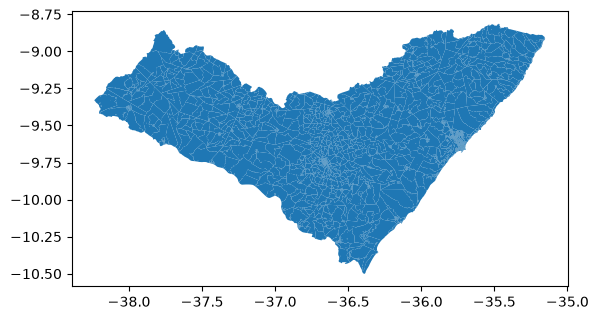

In [ ]:
census_tract = geobr.read_weighting_area(year=2010 )

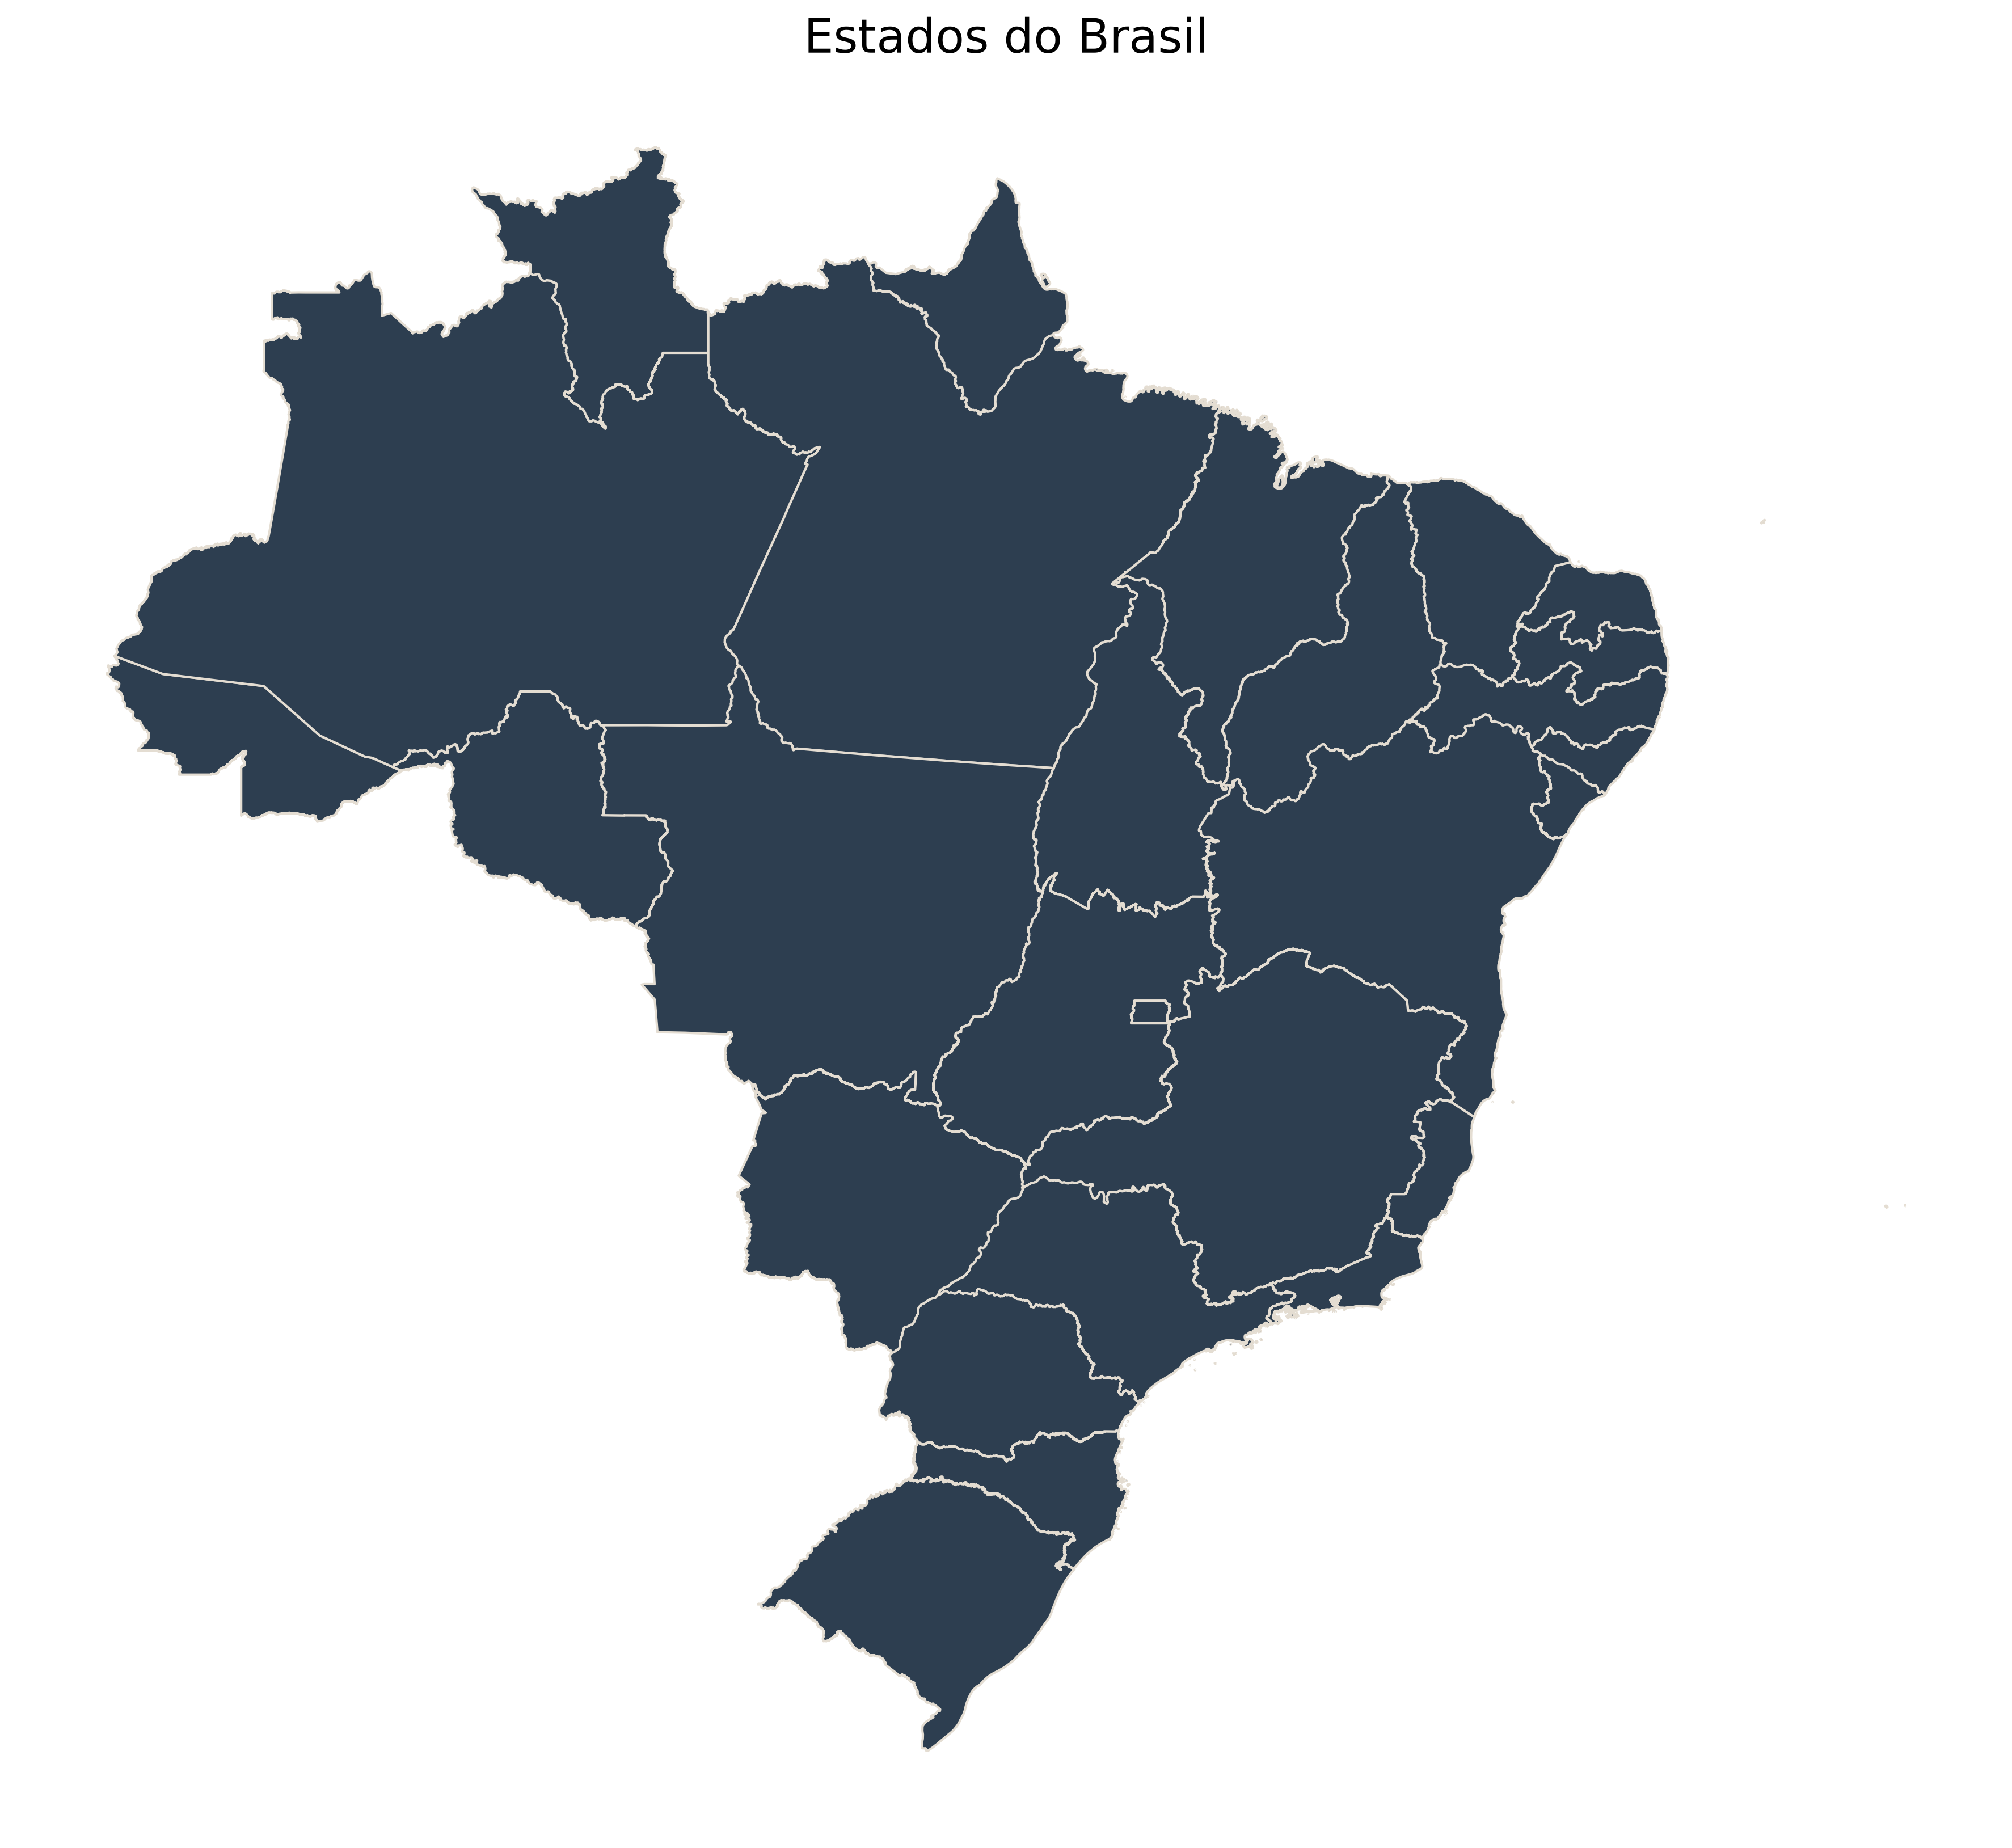

In [31]:
## facilmente baixar alguns dados e plotar
# plot brasil substates
states = geobr.read_state(year=2019)
# Plot all Brazilian states
fig, ax = plt.subplots(figsize=(15, 15), dpi=300)
states.plot(facecolor="#2D3E50", edgecolor="#E4DDD2", ax=ax)
ax.set_title("Estados do Brasil", fontsize=20)
ax.axis("off")
plt.show()

In [32]:
## vamos prosseguir com uma analise geoespacial

## o objetivo aqui eh unir os dados de municipio com dados de saude no estado de Alagoas

# All municipalities in the state of Alagoas
muni = geobr.read_municipality(code_muni="AL", year=2007)

In [33]:
muni.head()

,code_muni,name_muni,code_state,abbrev_state,name_state,code_region,name_region,year,geometry
0,2700102.0,Água Branca,27.0,AL,Alagoas,2.0,Nordeste,2007.0,"POLYGON ((-37.95433 -9.10956, -37.77101 -9.293..."
1,2700201.0,Anadia,27.0,AL,Alagoas,2.0,Nordeste,2007.0,"POLYGON ((-36.3512 -9.60725, -36.3205 -9.60824..."
2,2700300.0,Arapiraca,27.0,AL,Alagoas,2.0,Nordeste,2007.0,"POLYGON ((-36.6931 -9.63385, -36.65873 -9.6418..."
3,2700409.0,Atalaia,27.0,AL,Alagoas,2.0,Nordeste,2007.0,"POLYGON ((-35.93701 -9.40144, -35.93293 -9.480..."
4,2700508.0,Barra de Santo Antônio,27.0,AL,Alagoas,2.0,Nordeste,2007.0,"POLYGON ((-35.4638 -9.34776, -35.48746 -9.3746..."


In [34]:
muni.shape

(102, 9)

<Axes: >

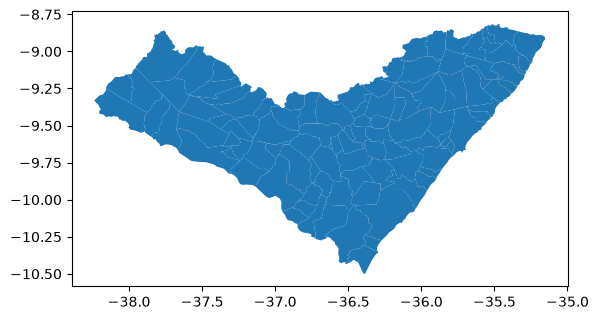

In [35]:
muni.plot()

In [36]:
# download dados de postos de saude/centros de saude/ UPA

df_upa = geobr.read_health_facilities(
    202604, 
    code_muni="AL"
)
df_upa

,code_muni,name_muni,co_unidade,co_cnes,nu_cnpj_mantenedora,tp_pfpj,nivel_dep,no_razao_social,no_fantasia,logradouro,...,lat_cnes,lon_cnes,lat_geocodebr,lon_geocodebr,precisao_geocodebr,tipo_resultado_geocodebr,desvio_metros_geocodebr,coords_source,date_update,geometry
0,2700102.0,Água Branca,2700100432245,0432245,12350153000148,3,3,MUNICIPIO DE AGUA BRANCA,ACADEMIA DE SAUDE DA VARZEA DO PICO,POVOADO VARZEA DO PICO,...,-9.265542,-37.941456,-9.267874,-37.921598,cep,dc02,11763,cnes,202604,POINT (-37.94146 -9.26554)
1,2700102.0,Água Branca,2700102008572,2008572,12350153000148,3,3,PREFEITURA MUNICIPAL DE AGUA BRANCA,ESF DO TABULEIRO,POVOADO TABULEIRO,...,-9.262365,-37.938216,-9.309525,-37.907174,logradouro,dl02,1476,cnes,202604,POINT (-37.93822 -9.26237)
2,2700102.0,Água Branca,2700102008580,2008580,12350153000148,3,3,PREFEITURA MUNICIPAL DE AGUA BRANCA,ESF DO ALTO DOS COELHOS,POVOADO ALTO DOS COELHOS,...,-9.262174,-37.937980,-9.351357,-37.904347,logradouro,dl02,1922,cnes,202604,POINT (-37.93798 -9.26217)
3,2700102.0,Água Branca,2700102008599,2008599,12350153000148,3,3,PREFEITURA MUNICIPAL DE AGUA BRANCA,ESF QUIXABEIRA,POVOADO QUIXABEIRA,...,-9.154300,-37.561700,-9.267874,-37.921598,cep,dc02,11763,cnes,202604,POINT (-37.5617 -9.1543)
4,2700102.0,Água Branca,2700102008602,2008602,12350153000148,3,3,PREFEITURA MUNICIPAL DE AGUA BRANCA,POSTO DE SAUDE PSICOSOCIAL,RUA CORONEL ULISSES LUNA,...,NaN,NaN,-9.264494,-37.937095,numero,dn01,6,geocodebr,202604,POINT (-37.9371 -9.26449)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5381,2709400.0,Viçosa,2709408092109,8092109,,3,1,INSTITUTO JOSEFA ALVES,IJAL,MUTIRAO CIDADE DE DEUS AREA 6 RUA C,...,-9.378165,-36.237101,-9.375950,-36.244140,cep,dc01,1718,cnes,202604,POINT (-36.2371 -9.37816)
5382,2709400.0,Viçosa,2709408092788,8092788,12333746000104,3,3,PREFEITURA MUNICIPAL D VICOSA,CENTRAL DE ABASTECIMENTO FARMACEUTICO CAF,RUA CLODOALDO DA FONSECA,...,-9.371988,-36.244408,-9.375950,-36.244140,cep,dc01,1718,cnes,202604,POINT (-36.24441 -9.37199)
5383,2709400.0,Viçosa,2709408266255,8266255,,3,1,INSTITUTO DEVINHO LOUREIRO,INSTITUTO DEVINHO LOUREIRO,RUA FREDERICO MAIA,...,-9.373302,-36.244101,-9.372685,-36.244494,numero,dn01,6,cnes,202604,POINT (-36.2441 -9.3733)
5384,2709400.0,Viçosa,2709409399968,9399968,12333746000104,3,3,MUNICIPIO DE VICOSA,USB DR JOSE MARIA DE MELO,AVENIDA JOAO PAULO II,...,-9.380026,-36.243757,-9.375950,-36.244140,cep,dc01,1718,cnes,202604,POINT (-36.24376 -9.38003)


In [37]:
df_upa.columns

Index(['code_muni', 'name_muni', 'co_unidade', 'co_cnes',
       'nu_cnpj_mantenedora', 'tp_pfpj', 'nivel_dep', 'no_razao_social',
       'no_fantasia', 'logradouro', 'numero_endereco', 'bairro', 'cep',
       'co_regiao_saude', 'co_micro_regiao', 'co_distrito_sanitario',
       'co_distrito_administrativo', 'nu_cpf', 'nu_cnpj', 'co_atividade',
       'co_clientela', 'nu_alvara', 'dt_expedicao', 'tp_orgao_expedidor',
       'dt_val_lic_sani', 'tp_lic_sani', 'tp_unidade', 'co_turno_atendimento',
       'to_char_dt_atualizacao_dd_mm_yyyy', 'co_usuario', 'co_cpfdiretorcln',
       'reg_diretorcln', 'st_adesao_filantrop', 'co_motivo_desab',
       'nu_latitude', 'nu_longitude', 'to_char_dt_atu_geo_dd_mm_yyyy',
       'no_usuario_geo', 'co_natureza_jur', 'tp_estab_sempre_aberto',
       'st_geracredito_gerente_sgif', 'st_conexao_internet', 'co_tipo_unidade',
       'no_fantasia_abrev', 'tp_gestao',
       'to_char_dt_atualizacao_origem_dd_mm_yyyy', 'co_tipo_estabelecimento',
       'co_ativ

In [38]:
df_upa['tp_unidade'].unique()

array([74,  1,  2, 15, 70, 64, 72, 68, 39, 40, 36, 71, 22,  5, 43,  4, 84,
       80, 73, 50,  7, 62, 69, 81, 76, 42, 75, 60, 79, 77, 85, 20, 82, 61,
       83], dtype=int32)

In [39]:
df_upa['name_state'].unique()

<ArrowStringArray>
['Alagoas']
Length: 1, dtype: str

In [40]:
## vamos checar quanta memoria RAM esses dois geodatasets estao consumindo
import os
import psutil

def ram_usage():
    process = psutil.Process(os.getpid())
    ram = process.memory_info().rss / 1024**3
    print(f"RAM usage: {ram:.2f} GB")

ram_usage()

RAM usage: 0.52 GB


In [41]:
muni.crs

<Geographic 2D CRS: EPSG:4674>
Name: SIRGAS 2000
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: Latin America - Central America and South America - onshore and offshore. Brazil - onshore and offshore.
- bounds: (-122.19, -59.87, -25.28, 32.72)
Datum: Sistema de Referencia Geocentrico para las AmericaS 2000
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [42]:
df_upa.crs

<Geographic 2D CRS: EPSG:4674>
Name: SIRGAS 2000
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: Latin America - Central America and South America - onshore and offshore. Brazil - onshore and offshore.
- bounds: (-122.19, -59.87, -25.28, 32.72)
Datum: Sistema de Referencia Geocentrico para las AmericaS 2000
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [43]:
assert muni.crs == df_upa.crs, f"Tem algo de errado aqui meu camarada"


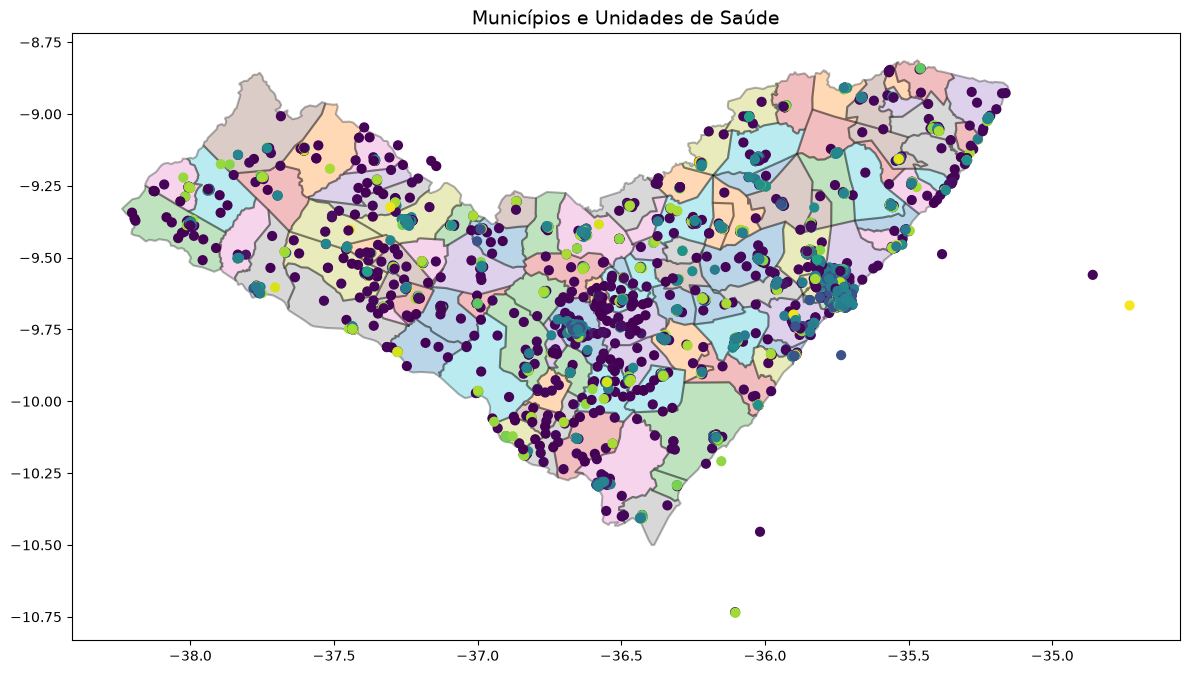

In [44]:


fig, ax = plt.subplots(figsize=(12, 10))
muni.plot(ax=ax, 
          column="name_muni", 
          alpha=0.3, 
          edgecolor="black", 
          linewidth=1.5, 
          legend=False)
df_upa.plot(ax=ax, 
            column="tp_unidade", 
            markersize=40, 
            legend=False,
            )
ax.set_title("Municípios e Unidades de Saúde", fontsize=14)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

Vamos primeiramente limpar esses dados.

Porque alguns pontos estao fora do estado de Alagoas? 

In [45]:
df_upa.shape

(5386, 68)

In [46]:
alagoas_estado = muni.dissolve()
# alagoas_estado.plot()

# spatial join to get all points in 
gdf_in_al = gpd.sjoin(
    df_upa,
    alagoas_estado,
    how='inner',
    predicate="within"
)

# get the points that are out of the state of alagoas 
gdf_out_al = df_upa.loc[
    ~df_upa.index.isin(gdf_in_al.index)
]
gdf_out_al.shape

(33, 68)

<Axes: >

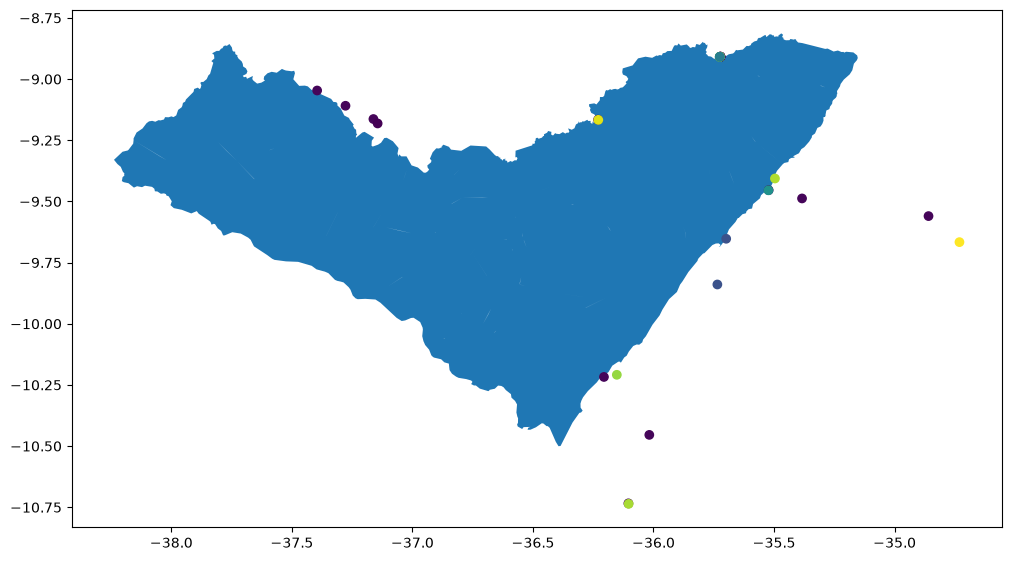

In [47]:
fig, ax = plt.subplots(figsize=(12, 10))
alagoas_estado.plot(ax=ax)
gdf_out_al.plot(ax=ax,
                column="tp_unidade", 
                )

In [48]:
gdf_out_al.head()

,code_muni,name_muni,co_unidade,co_cnes,nu_cnpj_mantenedora,tp_pfpj,nivel_dep,no_razao_social,no_fantasia,logradouro,...,lat_cnes,lon_cnes,lat_geocodebr,lon_geocodebr,precisao_geocodebr,tipo_resultado_geocodebr,desvio_metros_geocodebr,coords_source,date_update,geometry
626,2700508.0,Barra de Santo Antônio,2700507666098,7666098,12262713000102,3,3,MUNICIPIO DE BARRA DE SANTO ANTONIO,POLO ACADEMIA DA SAUDE,SEM INFORMACAO,...,-9.406208,-35.496140,-9.404294,-35.498959,cep,dc01,1329,cnes,202604,POINT (-35.49614 -9.40621)
937,2702108.0,Colônia Leopoldina,2702100850969,0850969,,3,1,L A CLINICA LTDA,L A CLINICA,LARGO DO MERCADO,...,-8.908794,-35.722175,-8.912705,-35.721044,cep,dc01,771,cnes,202604,POINT (-35.72217 -8.90879)
940,2702108.0,Colônia Leopoldina,2702102719134,2719134,12332987000120,3,3,PREFEITURA MUNICIPAL DE COLONIA LEOPOLDINA,AMBULATORIO DANIEL MONTEIRO DA CRUZ,DESTILARIA PORTO ALEGRE,...,-8.908434,-35.722690,-8.915334,-35.724137,cep,dc02,9798,cnes,202604,POINT (-35.72269 -8.90843)
941,2702108.0,Colônia Leopoldina,2702102719142,2719142,12332987000120,3,3,PREFEITURA MUNICIPAL DE COLONIA LEOPOLDINA,UNIDADE BASICA DE SAUDE USINA TAQUARA,USINA TAQUARA,...,-8.908752,-35.722346,-8.915334,-35.724137,cep,dc02,9798,cnes,202604,POINT (-35.72235 -8.90875)
942,2702108.0,Colônia Leopoldina,2702102719150,2719150,12332987000120,3,3,PREFEITURA MUNICIPAL DE COLONIA LEOPOLDINA,UNIDADE BASICA DE SAUDE JOSE LUIZ LESSA,RUA DA MANGUEIRA,...,-8.908857,-35.722454,-8.912705,-35.721044,cep,dc01,771,cnes,202604,POINT (-35.72245 -8.90886)


In [49]:
gdf_in_al.columns

Index(['code_muni_left', 'name_muni_left', 'co_unidade', 'co_cnes',
       'nu_cnpj_mantenedora', 'tp_pfpj', 'nivel_dep', 'no_razao_social',
       'no_fantasia', 'logradouro', 'numero_endereco', 'bairro', 'cep',
       'co_regiao_saude', 'co_micro_regiao', 'co_distrito_sanitario',
       'co_distrito_administrativo', 'nu_cpf', 'nu_cnpj', 'co_atividade',
       'co_clientela', 'nu_alvara', 'dt_expedicao', 'tp_orgao_expedidor',
       'dt_val_lic_sani', 'tp_lic_sani', 'tp_unidade', 'co_turno_atendimento',
       'to_char_dt_atualizacao_dd_mm_yyyy', 'co_usuario', 'co_cpfdiretorcln',
       'reg_diretorcln', 'st_adesao_filantrop', 'co_motivo_desab',
       'nu_latitude', 'nu_longitude', 'to_char_dt_atu_geo_dd_mm_yyyy',
       'no_usuario_geo', 'co_natureza_jur', 'tp_estab_sempre_aberto',
       'st_geracredito_gerente_sgif', 'st_conexao_internet', 'co_tipo_unidade',
       'no_fantasia_abrev', 'tp_gestao',
       'to_char_dt_atualizacao_origem_dd_mm_yyyy', 'co_tipo_estabelecimento',
     

In [50]:
# quantas unidades de saude por municipio?
resumo = gdf_in_al.groupby(["name_muni_left"]).agg(
    total_unidades=("co_unidade", "count"),
).reset_index()
print(resumo.to_string(index=False))
print(f'Total de unidades de saude:{resumo['total_unidades'].sum()}')

         name_muni_left  total_unidades
                 Anadia              21
              Arapiraca             515
                Atalaia              50
 Barra de Santo Antônio              15
    Barra de São Miguel              19
                Batalha              26
             Belo Monte              11
                  Belém              10
           Boca da Mata              34
             Branquinha              16
            Cacimbinhas              19
               Cajueiro              21
              Campestre               6
           Campo Alegre              46
           Campo Grande              11
                 Canapi              19
                 Capela              25
              Carneiros              13
              Chã Preta              12
          Coité do Nóia              20
     Colônia Leopoldina              11
          Coqueiro Seco              10
               Coruripe              54
                Craíbas              22


# Exercicio

Crie um mapa que demonstra o numero de unidades de saude por municipio de alagoas. 

<Axes: >

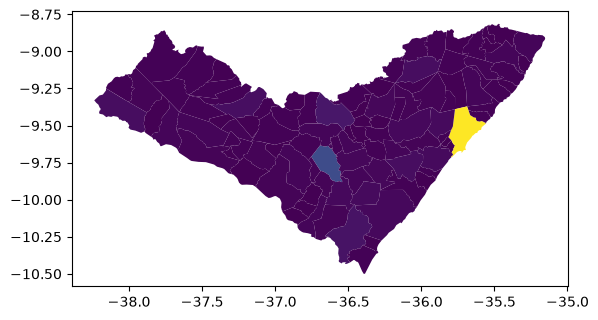

In [51]:
# SOLUCAO DO EXERCICIO

## CONTANDO O NUMERO DE UNIDADES DE SAUDE POR MUNICIPIO DE ALAGOAS
# agrega pelo numero de unidades 
total_unidades = gdf_in_al.groupby('name_muni_left').agg(
    total_unidade_saude = ("no_fantasia","count")
)

# junta essas unidades atrave da coluna de nome do municipio
muni_unidades = muni.join(
    total_unidades,
    how='inner',
    on='name_muni'
)

muni_unidades.plot(
    column='total_unidade_saude'
)

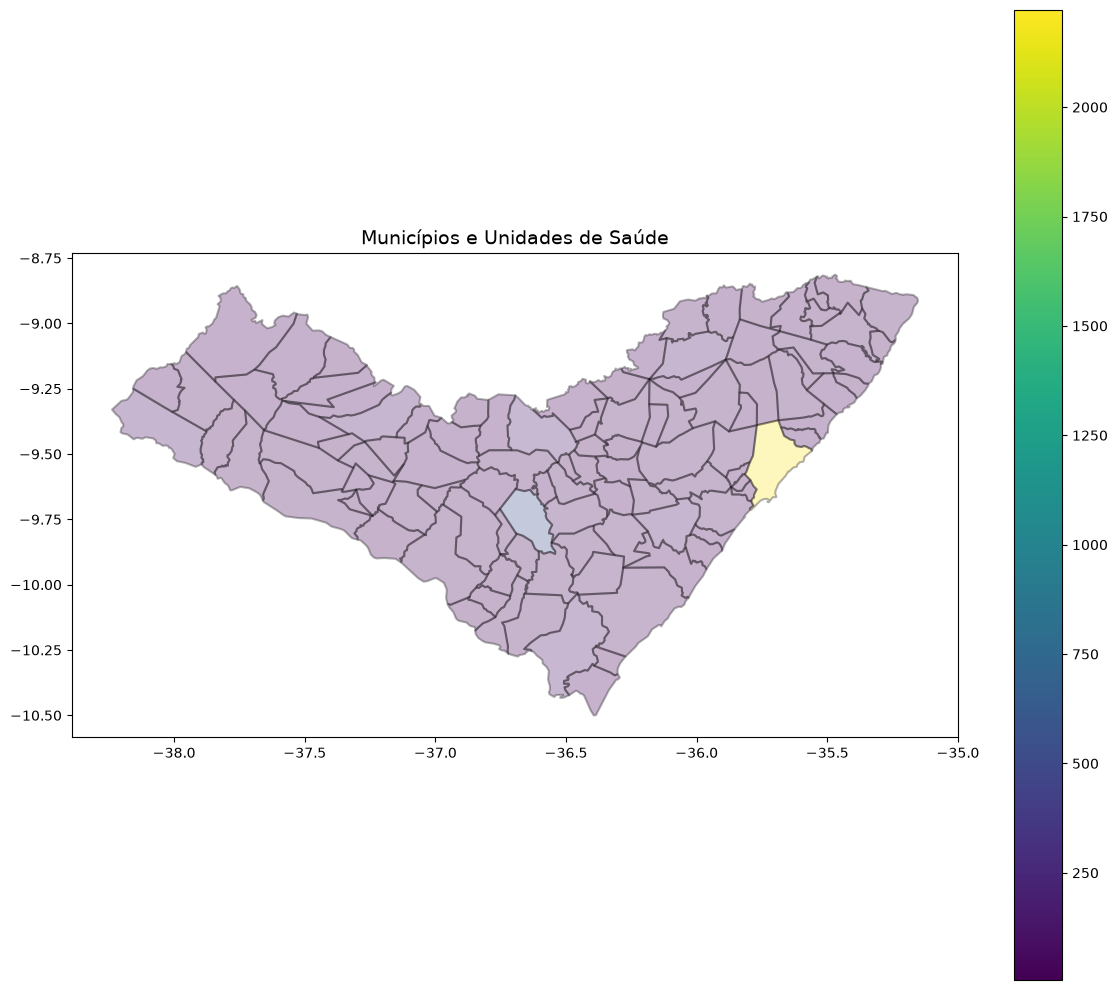

In [ ]:
# primeiro pegamos o numero de habitantes por municipio 


# vamos melhorar esse plot

fig, ax = plt.subplots(figsize=(12, 10))
muni_unidades.plot(ax=ax, 
          column="total_unidade_saude", 
          alpha=0.3, 
          edgecolor="black", 
          linewidth=1.5, 
          legend=True)

ax.set_title("Municípios e Unidades de Saúde", fontsize=14)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()